<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/BQm_EV6i0_j80CQZ8vcLvw/SN-web-lightmode.png" width=300 height=300 />


## Lab: Implementing the Functional API in Keras 

**Estimated time needed: 30 minutes**

In this lab, you will implement Keras functional API to build a neural network model. This lab will guide you through the steps of creating an input layer, adding hidden layers, and defining an output layer using the Functional API. 

##### Learning objectives: 

By the end of this lab, you will: 

- Use the Keras Functional API to build a simple neural network model. 

- Create an input layer, add hidden layers, and define an output layer using the Functional API. 

##### Prerequisites: 

- Basic understanding of Python programming 

- Familiarity with neural network concepts
  
- Keras and TensorFlow installed




#### Steps: 
**Step 1: Import Necessary Libraries**

Before you start, make sure to import the required libraries: TensorFlow and Keras. Keras is included within TensorFlow as `tensorflow.keras`. 


In [1]:
# Install TensorFlow
!pip install tensorflow==2.16.2

import tensorflow as tf 
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Input, Dense 
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')

Access is denied.


**Explanation:**

`!pip install tensorflow==2.16.2` installs the specified version of TensorFlow.

 `tensorflow` is the main library for machine learning in Python. 

 `Model` is used to create a model with the Functional API. 

 `Input` and `Dense` are types of layers that you will use in your model. 

 
**Step 2: Define the Input Layer**

You will define the input shape for your model. For simplicity, let's assume you are working with a dataset where each input is a vector of length 20. 

 


In [2]:
input_layer = Input(shape=(20,))
print(input_layer)

<KerasTensor shape=(None, 20), dtype=float32, sparse=False, ragged=False, name=keras_tensor>


**Explanation:**

`Input(shape=(20,))` creates an input layer that expects input vectors of length 20.

`print(input_layer)` shows the layer information, helping you understand the type of information you can get about the layers.


**Step 3: Add Hidden Layers**

Next, you will add a couple of hidden layers to your model. Hidden layers help the model learn complex patterns in the data.


In [3]:
hidden_layer1 = Dense(64, activation='relu')(input_layer) 
hidden_layer2 = Dense(64, activation='relu')(hidden_layer1) 

**Explanation:**

`Dense(64, activation='relu')` creates a dense (fully connected) layer with 64 units and ReLU activation function. 

Each hidden layer takes the output of the previous layer as its input. 

**Step 4: Define the Output Layer**

Finally, you will define the output layer. Suppose you are working on a binary classification problem, so the output layer will have one unit with a sigmoid activation function. 


In [4]:
output_layer = Dense(1, activation='sigmoid')(hidden_layer2) 

**Explanation:**

`Dense(1, activation='sigmoid')` creates a dense layer with 1 unit and a sigmoid activation function, suitable for binary classification. 

**Step 5: Create the Model**

Now, you will create the model by specifying the input and output layers. 


In [5]:
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

**Explanation:**

`Model(inputs=input_layer, outputs=output_layer)` creates a Keras model that connects the input layer to the output layer through the hidden layers. 

`model.summary()` provides a summary of the model, showing the layers, their shapes, and the number of parameters. This helps you interpret the model architecture.


**Step 6: Compile the Model**

Before training the model, you need to compile it. You will specify the loss function, optimizer, and evaluation metrics. 


In [7]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Explanation:**

`optimizer='adam'` specifies the Adam optimizer, a popular choice for training neural networks. 

`loss='binary_crossentropy'` specifies the loss function for binary classification problems. 

`metrics=['accuracy']` instructs Keras to evaluate the model using accuracy during training. 

**Step 7: Train the Model**

You can now train the model using training data. For this example, let's assume `X_train` is your training input data and `y_train` is the corresponding label. 


In [8]:
# Example data (in practice, use real dataset) 

import numpy as np 
X_train = np.random.rand(1000, 20) 
y_train = np.random.randint(2, size=(1000, 1)) 
model.fit(X_train, y_train, epochs=10, batch_size=32) 

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4680 - loss: 0.6987
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5010 - loss: 0.6953
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5350 - loss: 0.6896
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5480 - loss: 0.6875
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5710 - loss: 0.6843
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5800 - loss: 0.6810
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5920 - loss: 0.6776
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5670 - loss: 0.6782
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5910 - loss: 0.6727
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5850 - loss: 0.6709


**Explanation:**

`X_train` and `y_train` are placeholders for your actual training data. 

`model.fit` trains the model for a specified number of epochs and batch size. 

**Step 8: Evaluate the Model**

After training, you can evaluate the model on test data to see how well it performs. 


In [9]:
# Example test data (in practice, use real dataset) 

X_test = np.random.rand(200, 20) 
y_test = np.random.randint(2, size=(200, 1)) 
loss, accuracy = model.evaluate(X_test, y_test) 
print(f'Test loss: {loss}') 
print(f'Test accuracy: {accuracy}') 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5300 - loss: 0.6991 
Test loss: 0.6990888118743896
Test accuracy: 0.5299999713897705


**Explanation:**

`model.evaluate` computes the loss and accuracy of the model on test data. 

`X_test` and `y_test` are placeholders for your actual test data. 


### Dropout and Batch Normalization

Before we proceed with the practice exercise, let's briefly discuss two important techniques often used to improve the performance of neural networks: **Dropout Layers** and **Batch Normalization**.

#### Dropout Layers

Dropout is a regularization technique that helps prevent overfitting in neural networks. During training, Dropout randomly sets a fraction of input units to zero at each update cycle. This prevents the model from becoming overly reliant on any specific neurons, which encourages the network to learn more robust features that generalize better to unseen data.

**Key points:**
- Dropout is only applied during training, not during inference.
- The dropout rate is a hyperparameter that determines the fraction of neurons to drop.


#### Batch Normalization

Batch Normalization is a technique used to improve the training stability and speed of neural networks. It normalizes the output of a previous layer by re-centering and re-scaling the data, which helps in stabilizing the learning process. By reducing the internal covariate shift (the changes in the distribution of layer inputs), batch normalization allows the model to use higher learning rates, which often speeds up convergence.

**Key Points:**

- Batch normalization works by normalizing the inputs to each layer to have a mean of zero and a variance of one.
- It is applied during both training and inference, although its behavior varies slightly between the two phases.
- Batch normalization layers also introduce two learnable parameters that allow the model to scale and - shift the normalized output, which helps in restoring the model's representational power.


**Example of adding a Dropout layer in Keras:**


In [10]:
from tensorflow.keras.layers import Dropout, Dense, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(20,))

# Add a hidden layer
hidden_layer = Dense(64, activation='relu')(input_layer)

# Add a Dropout layer
dropout_layer = Dropout(rate=0.5)(hidden_layer)

# Add another hidden layer after Dropout
hidden_layer2 = Dense(64, activation='relu')(dropout_layer)

# Define the output layer
output_layer = Dense(1, activation='sigmoid')(hidden_layer2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Summary of the model
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

**Example of adding Batch Normalization in Keras:**


In [11]:
from tensorflow.keras.layers import BatchNormalization, Dense, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(20,))

# Add a hidden layer
hidden_layer = Dense(64, activation='relu')(input_layer)

# Add a BatchNormalization layer
batch_norm_layer = BatchNormalization()(hidden_layer)

# Add another hidden layer after BatchNormalization
hidden_layer2 = Dense(64, activation='relu')(batch_norm_layer)

# Define the output layer
output_layer = Dense(1, activation='sigmoid')(hidden_layer2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Summary of the model
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,825 (22.75 KB)

 Trainable params: 5,697 (22.25 KB)

 Non-trainable params: 128 (512.00 B)

### Practice exercises


> #### **Note** : The evaluation metrics here are based on placeholder data (`X_test`, `y_test`). In practice, use real, sufficiently large datasets to draw valid conclusions.


#### Exercise 1: Add Dropout Layers

**Objective:** Learn to add dropout layers to prevent overfitting.

**Instructions:**
1. Add dropout layers after each hidden layer in the model.
2. Set the dropout rate to 0.5.
3. Recompile, train, and evaluate the model.


In [12]:
from tensorflow.keras.layers import Dropout, Input, Dense
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(20,))

# Add hidden layers with dropout
hidden_layer1 = Dense(64, activation='relu')(input_layer)
dropout1 = Dropout(0.5)(hidden_layer1)
hidden_layer2 = Dense(64, activation='relu')(dropout1)
dropout2 = Dropout(0.5)(hidden_layer2)

# Define the output layer
output_layer = Dense(1, activation='sigmoid')(dropout2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5060 - loss: 0.7047
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5020 - loss: 0.7029
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.7049
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5220 - loss: 0.6912
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5110 - loss: 0.6948
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5320 - loss: 0.6917
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4960 - loss: 0.6971
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5330 - loss: 0.6882
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5430 - loss: 0.6878
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5350 - loss: 0.6945
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5350 - loss: 0.6919 
Test loss: 0.6919262409210205
Test accuracy: 0.5350000262260437


<details>
    <summary>Click here for Solution</summary>

```python
from tensorflow.keras.layers import Dropout, Input, Dense
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(20,))

# Add hidden layers with dropout
hidden_layer1 = Dense(64, activation='relu')(input_layer)
dropout1 = Dropout(0.5)(hidden_layer1)
hidden_layer2 = Dense(64, activation='relu')(dropout1)
dropout2 = Dropout(0.5)(hidden_layer2)

# Define the output layer
output_layer = Dense(1, activation='sigmoid')(dropout2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')
 ```   

</details>


#### Exercise 2: Change Activation Functions

**Objective:** Experiment with different activation functions.

**Instructions:**
1. Change the activation function of the hidden layers from ReLU to Tanh.
2. Recompile, train, and evaluate the model to see the effect.


In [13]:
## Write your code here
from tensorflow.keras.layers import Dropout, Input, Dense
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(20,))

# Add hidden layers with dropout
hidden_layer1 = Dense(64, activation='tanh')(input_layer)
dropout1 = Dropout(0.5)(hidden_layer1)
hidden_layer2 = Dense(64, activation='tanh')(dropout1)
dropout2 = Dropout(0.5)(hidden_layer2)

# Define the output layer
output_layer = Dense(1, activation='sigmoid')(dropout2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4730 - loss: 0.7528
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5090 - loss: 0.7336
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4960 - loss: 0.7215
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5290 - loss: 0.7006
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5050 - loss: 0.7155
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5280 - loss: 0.7018
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5130 - loss: 0.7066
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5410 - loss: 0.7060
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5180 - loss: 0.7032
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5030 - loss: 0.7094
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5150 - loss: 0.6968  
Test loss: 0.6968065500259399
Test accuracy: 0.5149999856948853


<details>
    <summary>Click here for Solution</summary>

```python
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(20,))

# Add hidden layers with Tanh activation
hidden_layer1 = Dense(64, activation='tanh')(input_layer)
hidden_layer2 = Dense(64, activation='tanh')(hidden_layer1)

# Define the output layer
output_layer = Dense(1, activation='sigmoid')(hidden_layer2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')
 ```   

</details>


#### Exercise 3: Use Batch Normalization

**Objective:** Implement batch normalization to improve training stability.

**Instructions:**
1. Add batch normalization layers after each hidden layer.
2. Recompile, train, and evaluate the model.


In [14]:
## Write your code here
from tensorflow.keras.layers import Dropout, Input, Dense
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(20,))

# Add hidden layers with dropout
hidden_layer1 = Dense(64, activation='relu')(input_layer)
batch_norm1 = BatchNormalization()(hidden_layer1)
hidden_layer2 = Dense(64, activation='relu')(batch_norm1)
batch_norm2 = BatchNormalization()(hidden_layer2)

# Define the output layer
output_layer = Dense(1, activation='sigmoid')(batch_norm2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,081 (23.75 KB)

 Trainable params: 5,825 (22.75 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4920 - loss: 0.8014
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5690 - loss: 0.6936
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5870 - loss: 0.6677
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6020 - loss: 0.6483
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6470 - loss: 0.6255
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6650 - loss: 0.6116
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6640 - loss: 0.5979
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6990 - loss: 0.5850
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7320 - loss: 0.5588
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7410 - loss: 0.5431
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5150 - loss: 0.7314  
Test loss: 0.7314123511314392
Test accuracy: 0.5149999856948853


<details>
    <summary>Click here for Solution</summary>

```python
from tensorflow.keras.layers import BatchNormalization

# Define the input layer
input_layer = Input(shape=(20,))

# Add hidden layers with batch normalization
hidden_layer1 = Dense(64, activation='relu')(input_layer)
batch_norm1 = BatchNormalization()(hidden_layer1)
hidden_layer2 = Dense(64, activation='relu')(batch_norm1)
batch_norm2 = BatchNormalization()(hidden_layer2)

# Define the output layer
output_layer = Dense(1, activation='sigmoid')(batch_norm2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')
 ```   

</details>


##### How to ACTUALLY compare accuracy

You need to train 3 separate models and record their results.

##### 🧪 Step 1 — Baseline model

In [18]:
model_baseline = Model(inputs=input_layer, outputs=output_layer)
model_baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_baseline = model_baseline.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model_baseline.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8988 - loss: 0.2779 - val_accuracy: 0.6000 - val_loss: 0.8557
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9325 - loss: 0.2423 - val_accuracy: 0.5650 - val_loss: 0.9098
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9287 - loss: 0.2335 - val_accuracy: 0.5750 - val_loss: 0.9444
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9400 - loss: 0.2194 - val_accuracy: 0.5650 - val_loss: 0.9518
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9413 - loss: 0.2191 - val_accuracy: 0.5800 - val_loss: 1.0027
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9513 - loss: 0.1892 - val_accuracy: 0.5900 - val_loss: 0.9807
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9450 - loss: 0.1985 - val_accuracy: 0.5700 - val_loss: 1.0400
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9450 - loss: 0.1918 - val_accuracy: 0.5450 - val_los

##### Step 2 — Dropout model

In [19]:
from tensorflow.keras.layers import Dropout

hidden1 = Dense(64, activation='relu')(input_layer)
drop1 = Dropout(0.5)(hidden1)
hidden2 = Dense(64, activation='relu')(drop1)
drop2 = Dropout(0.5)(hidden2)
output = Dense(1, activation='sigmoid')(drop2)

model_dropout = Model(inputs=input_layer, outputs=output)
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model_dropout.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5175 - loss: 0.7220 - val_accuracy: 0.5050 - val_loss: 0.6939
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5088 - loss: 0.7173 - val_accuracy: 0.5250 - val_loss: 0.6916
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.7027 - val_accuracy: 0.5100 - val_loss: 0.6926
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5225 - loss: 0.6983 - val_accuracy: 0.5050 - val_loss: 0.6918
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5138 - loss: 0.6978 - val_accuracy: 0.5350 - val_loss: 0.6906
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5300 - loss: 0.6917 - val_accuracy: 0.5400 - val_loss: 0.6920
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.6991 - val_accuracy: 0.5200 - val_loss: 0.6912
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5138 - loss: 0.6966 - val_accuracy: 0.5250 - val_loss

#### 🧪 Step 3 — Batch Normalization model

In [20]:
from tensorflow.keras.layers import BatchNormalization

hidden1 = Dense(64, activation='relu')(input_layer)
bn1 = BatchNormalization()(hidden1)
hidden2 = Dense(64, activation='relu')(bn1)
bn2 = BatchNormalization()(hidden2)
output = Dense(1, activation='sigmoid')(bn2)

model_bn = Model(inputs=input_layer, outputs=output)
model_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_bn = model_bn.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model_bn.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4925 - loss: 0.8531 - val_accuracy: 0.4900 - val_loss: 0.6956
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5638 - loss: 0.7132 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5938 - loss: 0.6710 - val_accuracy: 0.5000 - val_loss: 0.6962
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6438 - loss: 0.6380 - val_accuracy: 0.5100 - val_loss: 0.7043
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6350 - loss: 0.6176 - val_accuracy: 0.5250 - val_loss: 0.7094
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6925 - loss: 0.5991 - val_accuracy: 0.5200 - val_loss: 0.7143
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6988 - loss: 0.5787 - val_accuracy: 0.5150 - val_loss: 0.7276
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7100 - loss: 0.5706 - val_accuracy: 0.5150 - val_lo

#### 📊 Step 4 — Compare accuracy

In [21]:
print("Baseline Accuracy:", model_baseline.evaluate(X_test, y_test)[1])
print("Dropout Accuracy:", model_dropout.evaluate(X_test, y_test)[1])
print("BatchNorm Accuracy:", model_bn.evaluate(X_test, y_test)[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4250 - loss: 1.4698
Baseline Accuracy: 0.42500001192092896
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5200 - loss: 0.6938 
Dropout Accuracy: 0.5199999809265137
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5550 - loss: 0.7237
BatchNorm Accuracy: 0.5550000071525574


#### When both are combine in the model

In [39]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
import tensorflow as tf

# Input layer (use same shape as your dataset)
input_layer = Input(shape=(X_train.shape[1],))

# Block 1
x = Dense(64)(input_layer)
x = BatchNormalization()(x)
x = tf.keras.activations.relu(x)
x = Dropout(0.3)(x)

# Block 2
x = Dense(64)(x)
x = BatchNormalization()(x)
x = tf.keras.activations.relu(x)
x = Dropout(0.3)(x)

# Output layer
output_layer = Dense(1, activation='sigmoid')(x)

# Build model
model_combined = Model(inputs=input_layer, outputs=output_layer)

# Compile
model_combined.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_combined = model_combined.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)
# Evaluate the model
loss, accuracy = model_combined.evaluate(X_test, y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5113 - loss: 0.8115 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5238 - loss: 0.7617 - val_accuracy: 0.4750 - val_loss: 0.6928
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5375 - loss: 0.7417 - val_accuracy: 0.5400 - val_loss: 0.6932
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5500 - loss: 0.7254 - val_accuracy: 0.5300 - val_loss: 0.6938
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5075 - loss: 0.7259 - val_accuracy: 0.5350 - val_loss: 0.6928
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.7298 - val_accuracy: 0.5300 - val_loss: 0.6933
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5587 - loss: 0.7013 - val_accuracy: 0.5300 - val_loss: 0.6955
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5725 - loss: 0.7011 - val_accuracy: 0.4950 - val_los

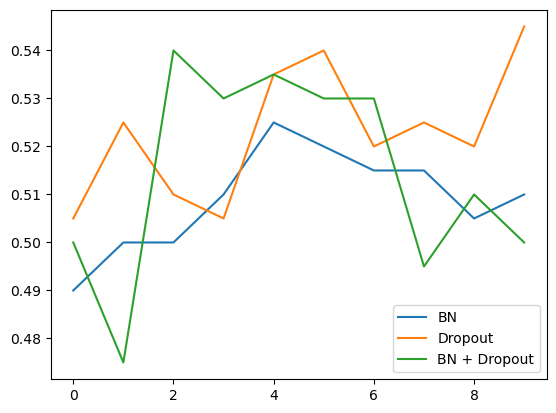

In [41]:
import matplotlib.pyplot as plt
plt.plot(history_bn.history['val_accuracy'])
plt.plot(history_dropout.history['val_accuracy'])
plt.plot(history_combined.history['val_accuracy'])
plt.legend(['BN', 'Dropout', 'BN + Dropout'])
plt.show()

In [42]:
print("Combined Model Accuracy:", model_combined.evaluate(X_test, y_test)[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4850 - loss: 0.7057 
Combined Model Accuracy: 0.48500001430511475


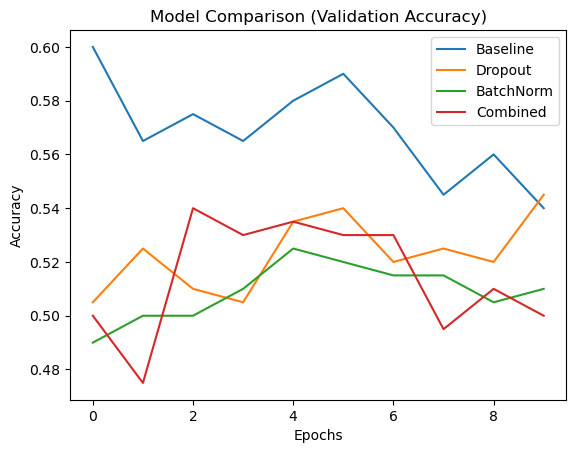

In [43]:
import matplotlib.pyplot as plt

plt.plot(history_baseline.history['val_accuracy'])
plt.plot(history_dropout.history['val_accuracy'])
plt.plot(history_bn.history['val_accuracy'])
plt.plot(history_combined.history['val_accuracy'])

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Baseline', 'Dropout', 'BatchNorm', 'Combined'])

plt.show()

### Summary

By completing these exercises, students will:

1. Understand the impact of dropout layers on model overfitting.
2. Learn how different activation functions affect model performance.
3. Gain experience with batch normalization to stabilize and accelerate training.


**Conclusion:**

You have successfully created, trained, and evaluated a simple neural network model using the Keras Functional API. This foundational knowledge will allow you to build more complex models and explore advanced functionalities in Keras. 


Copyright © IBM Corporation. All rights reserved.
